In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

import sys, os
sys.path.append('..')

from models.nist.refractive_index import ciddor
from datetime import datetime, timedelta


# Color palette for publication-quality figures
PUB_GRAY = '#cecece'
PUB_PURPLE = '#a559aa'
PUB_TEAL = '#59a89c'
PUB_GOLD = '#f0c571'
PUB_RED = '#e02b35'
PUB_BLUE = '#082a54'

# Configure global plot settings
plt.rcParams.update({
    # Font settings
    'font.size': 14,
    'font.family': 'Helvetica',
    'mathtext.fontset': 'stix',
    
    # Figure settings
    'figure.figsize': [10, 6],
    'figure.dpi': 300,
    
    # Axis settings
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.grid': True,
    'axes.titlesize': 14,
    
    # Line settings
    'lines.linewidth': 1,
    'lines.markersize': 6,
    'lines.markeredgewidth': 1,
    
    # Tick settings
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    
    # Legend settings
    'legend.fontsize': 14,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': False,
    'legend.framealpha': 0.95,
    
    # Save settings
    'savefig.bbox': 'tight',
    'savefig.dpi': 300,
    'savefig.format': 'pdf'
})


def check_data_quality(df):
    """
    Comprehensive data quality assessment
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataset to check
    """
    print("Missing Value Check:")
    print(df.isnull().sum())
    
    print("\nDescriptive Statistics:")
    print(df.describe())


def analyze_regression(df, n_bootstrap=2000):
    """
    Regression analysis with HAC standard errors, bootstrap, and error-in-variables analysis
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataset with environmental variables and refractive index
    n_bootstrap : int
        Number of bootstrap iterations
        
    Returns:
    --------
    dict
        Comprehensive regression results including models, parameters, and diagnostics
    """
    print("Performing regression analysis...")
    
    # 1. Prepare data (exactly as in original function)
    X_original = df[['temperature', 'humidity', 'pressure']].copy()
    X_original['pressure'] = X_original['pressure'] * 100  # Convert to Pascals
    y = df['n_1762']
    
    # Calculate means for centering
    T_mean = X_original['temperature'].mean()
    H_mean = X_original['humidity'].mean()
    P_mean = X_original['pressure'].mean()
    y_mean = y.mean()
    
    # 2. Original OLS with constant
    print("\n1. Original OLS with constant:")
    X_with_const = sm.add_constant(X_original)
    model_original = sm.OLS(y, X_with_const).fit()
    print(model_original.summary())
    
    # 3. Centered OLS (without constant)
    print("\n2. Centered OLS (without constant):")
    X_centered = X_original.copy()
    X_centered['temperature'] = X_original['temperature'] - T_mean
    X_centered['humidity'] = X_original['humidity'] - H_mean
    X_centered['pressure'] = X_original['pressure'] - P_mean
    
    model_centered = sm.OLS(y, X_centered).fit()
    print(model_centered.summary())
    
    # 4. Calculate corrected coefficients from centering
    coef_temp = model_centered.params['temperature']
    coef_hum = model_centered.params['humidity']
    coef_pres = model_centered.params['pressure']
    
    # Constant term = y_mean - Σ(coefficient × mean)
    const_corrected = y_mean - (coef_temp * T_mean + coef_hum * H_mean + coef_pres * P_mean)
    
    print(f"\n3. Corrected coefficients from centering:")
    print(f"   const: {const_corrected:.12e}")
    print(f"   temperature: {coef_temp:.12e}")
    print(f"   humidity: {coef_hum:.12e}")
    print(f"   pressure: {coef_pres:.12e}")
    
    # 5. Check consistency with original model
    print(f"\n4. Comparison with original OLS:")
    print(f"   const diff: {abs(const_corrected - model_original.params['const']):.2e}")
    print(f"   temp diff: {abs(coef_temp - model_original.params['temperature']):.2e}")
    print(f"   hum diff: {abs(coef_hum - model_original.params['humidity']):.2e}")
    print(f"   pres diff: {abs(coef_pres - model_original.params['pressure']):.2e}")
    
    # 6. HAC (Newey-West) standard errors - EXACTLY as in original function
    print("\n5. OLS with Newey-West standard errors (HAC):")
    model_hac = sm.OLS(y, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    print(model_hac.summary())
    model_hac_auto = sm.OLS(y, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': None})
    print(model_hac_auto.summary())
    
    # 7. Prais-Winsten GLS for autocorrelation correction
    print("\n6. Prais-Winsten GLS:")
    from statsmodels.regression.linear_model import GLS
    from statsmodels.regression.linear_model import GLSAR
    # Estimate AR(1) coefficient
    resid_original = model_original.resid
    rho = np.corrcoef(resid_original[1:], resid_original[:-1])[0, 1]
    print(f"Estimated AR(1) coefficient: {rho:.3f}")
    
    # Prais-Winsten transformation
    y_pw = y.copy()
    X_pw = X_with_const.copy()
    
    # Transform first observation
    y_pw.iloc[0] = y.iloc[0] * np.sqrt(1 - rho**2)
    X_pw.iloc[0] = X_with_const.iloc[0] * np.sqrt(1 - rho**2)
    
    # Transform remaining observations
    for t in range(1, len(y)):
        y_pw.iloc[t] = y.iloc[t] - rho * y.iloc[t-1]
        X_pw.iloc[t] = X_with_const.iloc[t] - rho * X_with_const.iloc[t-1]
    
    model_pw = sm.OLS(y_pw, X_pw).fit()
    print("\nPrais-Winsten GLS Results:")
    print(model_pw.summary())
    
    # 8. Bootstrap - EXACTLY as in original function
    print(f"\n7. Performing Bootstrap (n={n_bootstrap})...")
    
    bootstrap_results = []
    for i in range(n_bootstrap):
        if i % 500 == 0:
            print(f"  Completed {i}/{n_bootstrap} iterations")
        
        # Simple resampling (EXACTLY as in original function)
        indices = np.random.choice(len(df), size=len(df), replace=True)
        sample_df = df.iloc[indices]
        
        # Prepare X matrix for sample (EXACTLY as in original function)
        X_sample = sm.add_constant(sample_df[['temperature', 'humidity', 'pressure']])
        X_sample['pressure'] = X_sample['pressure'] * 100
        y_sample = sample_df['n_1762']
        
        try:
            model_sample = sm.OLS(y_sample, X_sample).fit()
            bootstrap_results.append(model_sample.params)
        except:
            continue
    
    bootstrap_params = np.array(bootstrap_results)
    
    # Calculate bootstrap confidence intervals
    bootstrap_95_lower = np.percentile(bootstrap_params, 2.5, axis=0)
    bootstrap_95_upper = np.percentile(bootstrap_params, 97.5, axis=0)
    
    # 9. Error-in-variables Monte Carlo simulation (optional addition)
    print("\n8. Performing Error-in-Variables Monte Carlo Simulation...")
    n_simulations = 2000
    eiv_results = []
    
    sensor_errors = {
        'temperature': 0.5,    # °C
        'humidity': 3.0,       # %
        'pressure': 12.0       # Pa
    }
    
    # Pre-compute systematic offsets for efficiency
    systematic_offsets = {col: np.random.uniform(-error, error, n_simulations) 
                         for col, error in sensor_errors.items()}
    
    for i in range(n_simulations):
        if i % 500 == 0:
            print(f"Completed {i}/{n_simulations} EIV simulations")
        
        X_perturbed = X_with_const.copy()
        for col in sensor_errors:
            if col in X_perturbed.columns:
                systematic_offset = systematic_offsets[col][i]
                random_noise = np.random.normal(0, sensor_errors[col]/3, len(X_with_const))
                X_perturbed[col] = X_with_const[col] + systematic_offset + random_noise
        
        model_eiv = sm.OLS(y, X_perturbed).fit()
        eiv_results.append(model_eiv.params)
    
    eiv_params = np.array(eiv_results)
    eiv_systematic_error = np.std(eiv_params, axis=0)
    
    # 10. Create comprehensive results summary
    print("\n9. Comprehensive Results Summary:")
    results_summary = pd.DataFrame({
        'Variable': X_with_const.columns,
        'Original_OLS_Coefficient': model_original.params,
        'Original_OLS_SE': model_original.bse,
        'HAC_SE': model_hac.bse,
        'Prais_Winsten_Coefficient': model_pw.params,
        'Prais_Winsten_SE': model_pw.bse,
        'Bootstrap_95_Lower': bootstrap_95_lower,
        'Bootstrap_95_Upper': bootstrap_95_upper,
        'EIV_Systematic_Error': eiv_systematic_error
    })
    
    print(results_summary.round(12))
    
    # 11. Additional diagnostic tests
    print("\n10. Additional Diagnostics:")
    
    # Durbin-Watson statistic
    dw_original = sm.stats.stattools.durbin_watson(model_original.resid)
    dw_pw = sm.stats.stattools.durbin_watson(model_pw.resid)
    print(f"Durbin-Watson Statistic:")
    print(f"  Original OLS: {dw_original:.3f}")
    print(f"  Prais-Winsten: {dw_pw:.3f}")
    
    # Breusch-Godfrey autocorrelation test
    try:
        bg_test = acorr_breusch_godfrey(model_original, nlags=5)
        print(f"Breusch-Godfrey Test (lag=5): LM={bg_test[0]:.3f}, p-value={bg_test[1]:.3f}")
    except:
        print("Breusch-Godfrey test failed")
    
    # Heteroscedasticity test
    try:
        bp_test = het_breuschpagan(model_original.resid, model_original.model.exog)
        print(f"Breusch-Pagan Heteroscedasticity Test: LM={bp_test[0]:.3f}, p-value={bp_test[1]:.3f}")
    except:
        print("Breusch-Pagan test failed")
    
    # Variance Inflation Factor for multicollinearity
    try:
        vif_data = pd.DataFrame()
        vif_data["Variable"] = X_with_const.columns
        vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                          for i in range(X_with_const.shape[1])]
        print("\nVariance Inflation Factors (VIF):")
        print(vif_data)
    except:
        print("VIF calculation failed")
    
    return {
        'model_original': model_original,
        'model_centered': model_centered,
        'model_hac': model_hac,
        'model_pw': model_pw,
        'bootstrap_params': bootstrap_params,
        'bootstrap_95_lower': bootstrap_95_lower,
        'bootstrap_95_upper': bootstrap_95_upper,
        'eiv_params': eiv_params,
        'eiv_systematic_error': eiv_systematic_error,
        'results_summary': results_summary,
        'dw_original': dw_original,
        'dw_pw': dw_pw,
        'rho_estimate': rho if 'rho' in locals() else None,
        'vif_data': vif_data if 'vif_data' in locals() else None
    }


def plot_diagnostics(results, df):
    """
    Diagnostic plots for regression analysis
    
    Parameters:
    -----------
    results : dict
        Regression results from analyze_regression
    df : pandas.DataFrame
        Original dataset
    """
    # Use model_original instead of ols_model
    model_ols = results['model_original']
    
    # Create 2x2 subplot layout
    fig, axes = plt.subplots(2, 2, figsize=(8.6, 6))
    fig.suptitle('Regression Diagnostics', fontsize=16, fontweight='bold')
    
    # 1. Residual autocorrelation function
    sm.graphics.tsa.plot_acf(model_ols.resid, lags=40, alpha=0.05, ax=axes[0,0])
    axes[0,0].set_title('Residual Autocorrelation', fontsize=12)
    axes[0,0].set_xlabel('Lag')
    axes[0,0].set_ylabel('Autocorrelation')
    axes[0,0].set_ylim(0,1)
    
    # 2. Residual partial autocorrelation function
    sm.graphics.tsa.plot_pacf(model_ols.resid, lags=40, alpha=0.05, ax=axes[0,1])
    axes[0,1].set_title('Residual Partial Autocorrelation', fontsize=12)
    axes[0,1].set_xlabel('Lag')
    axes[0,1].set_ylabel('Partial Autocorrelation')
    axes[0,1].set_ylim(0,1)
    
    # 3. Standard error comparison
    summary = results['results_summary']
    variables = summary['Variable'][1:].values  # Exclude constant
    ols_errors = summary['Original_OLS_SE'][1:].values  # Changed from 'OLS_SE'
    hac_errors = summary['HAC_SE'][1:].values
    
    x_pos = np.arange(len(variables))
    width = 0.35
    
    axes[1,0].bar(x_pos - width/2, ols_errors, width, label='OLS SE', alpha=0.7, 
                 color='steelblue', edgecolor='black', linewidth=0.5)
    axes[1,0].bar(x_pos + width/2, hac_errors, width, label='HAC SE', alpha=0.7,
                 color='lightcoral', edgecolor='black', linewidth=0.5)
    axes[1,0].set_xlabel('Variable')
    axes[1,0].set_ylabel('Standard Error')
    axes[1,0].set_title('Standard Error Comparison', fontsize=12)
    axes[1,0].set_xticks(x_pos)
    axes[1,0].set_xticklabels(variables, rotation=45, ha='right')
    axes[1,0].legend()
    
    # 4. Residual distribution
    residuals = model_ols.resid
    axes[1,1].hist(residuals, bins=30, alpha=0.7, color='lightgreen', 
                  edgecolor='black', linewidth=0.5)
    axes[1,1].axvline(x=0, color='red', linestyle='--', linewidth=1)
    axes[1,1].set_xlabel('Residual Value')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].set_title('Residual Distribution', fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    # Additional time series plots
    fig2, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.6, 6))
    
    # Residual time series
    ax1.plot(df.index, model_ols.resid, 'o-', markersize=2, linewidth=0.5, 
            color='navy', alpha=0.7)
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Residuals')
    ax1.set_title('Residual Time Series', fontsize=12)
    
    # Bootstrap coefficient distributions
    bootstrap_params = results['bootstrap_params']
    colors = ['steelblue', 'lightcoral', 'lightgreen']
    for i, var in enumerate(variables):
        ax2.hist(bootstrap_params[:, i+1], alpha=0.7, label=var, bins=30,
                color=colors[i], edgecolor='black', linewidth=0.5)
    ax2.set_xlabel('Coefficient Value')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Bootstrap Coefficient Distributions', fontsize=12)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


def plot_environmental_dependence(df, bin_size=0.3, figsize=(8.6, 6)):
    """
    Environmental dependence plot with error bars
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataset with environmental variables and refractive index
    bin_size : float
        Bin size for grouping environmental variables
    figsize : tuple
        Figure dimensions
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle('Environmental Dependence of Refractive Index', fontsize=16, fontweight='bold')
    
    # Create bins for environmental variables
    df['temp_bin'] = (df['temperature'] // bin_size) * bin_size
    df['humidity_bin'] = (df['humidity'] // bin_size) * bin_size
    df['pressure_bin'] = (df['pressure'] // bin_size) * bin_size
    
    colors = ['steelblue', 'lightcoral', 'lightgreen']
    titles = ['Temperature', 'Humidity', 'Pressure']
    xlabels = ['Temperature (°C)', 'Humidity (%)', 'Pressure (hPa)']
    
    for i, (var, ax, color, title, xlabel) in enumerate(zip(
        ['temp_bin', 'humidity_bin', 'pressure_bin'], axes, colors, titles, xlabels)):
        
        group = df.groupby(var)['n_1762'].agg(['mean', 'std', 'count'])
        group = group[group['count'] > 15]  # Minimum sample size
        
        # Calculate refractive index offset (n-1) × 10^4
        y_values = (group['mean'] - 1) * 1e4
        y_errors = group['std'] * 1e4
        
        ax.errorbar(group.index, y_values, yerr=y_errors, fmt='o', 
                   color=color, markersize=4, capsize=3, linewidth=1,
                   ecolor=color, elinewidth=1, alpha=0.8)
        
        ax.set_xlabel(xlabel)
        ax.set_title(title, fontsize=12)
        if i == 0:
            ax.set_ylabel(r'Refractive Index $(n - 1) \times 10^{4}$')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()


def visualize_data(df):
    """
    Data visualization
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataset to visualize
    """
    # Variable distributions
    fig, axes = plt.subplots(2, 2, figsize=(8.6, 6))
    fig.suptitle('Variable Distributions', fontsize=16, fontweight='bold')
    
    variables = ['n_1762', 'temperature', 'humidity', 'pressure']
    titles = ['Refractive Index', 'Temperature', 'Humidity', 'Pressure']
    colors = ['steelblue', 'lightcoral', 'lightgreen', 'goldenrod']
    
    for i, (var, title, color) in enumerate(zip(variables, titles, colors)):
        row, col = i // 2, i % 2
        axes[row, col].hist(df[var], bins=30, alpha=0.7, color=color,
                          edgecolor='black', linewidth=0.5)
        axes[row, col].set_xlabel(title)
        axes[row, col].set_ylabel('Frequency')
        axes[row, col].set_title(title + ' Distribution', fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
    
    # Correlation matrix
    variables = ['n_1762', 'temperature', 'humidity', 'pressure']
    df_plot = df[variables].copy()
    df_plot.columns = ['Refractive\nIndex', 'Temperature', 'Humidity', 'Pressure']
    
    corr_matrix = df_plot.corr()
    
    fig, ax = plt.subplots(figsize=(8.6, 6))
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    
    # Add correlation values
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                   ha='center', va='center', fontsize=10,
                   color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
    
    ax.set_xticks(range(len(corr_matrix)))
    ax.set_yticks(range(len(corr_matrix)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.columns)
    ax.set_title('Correlation Matrix', fontsize=14)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20)
    
    plt.tight_layout()
    plt.show()


def create_uncertainty_budget(results):
    """
    Uncertainty budget table
    
    Parameters:
    -----------
    results : dict
        Regression results from analyze_regression
        
    Returns:
    --------
    pandas.DataFrame
        Uncertainty budget table
    """
    summary = results['results_summary']
    
    uncertainty_budget = pd.DataFrame({
        'Uncertainty Source': [
            'Finite sample & serial correlation',
            'Temperature sensor calibration',
            'Humidity sensor calibration', 
            'Pressure sensor calibration',
            '780 nm frequency reference',
            '1762 nm frequency reference',
            'Interferometer non-linearity',
            'Spatial/temporal mismatch'
        ],
        'Affected Parameter': [
            'All coefficients',
            r'$\alpha_T$',
            r'$\alpha_H$', 
            r'$\alpha_P$',
            'Constant term',
            'Constant term',
            'All coefficients',
            'Residual variance'
        ],
        'Estimation Method': [
            'HAC + Block Bootstrap',
            'EIV Monte Carlo',
            'EIV Monte Carlo',
            'EIV Monte Carlo', 
            'Analytical propagation',
            'Analytical propagation',
            'Upper-bound estimate',
            'Residual analysis'
        ],
        'Magnitude (1σ)': [
            f"{np.mean(summary['HAC_SE'][1:].values):.2e}",
            f"{summary[summary['Variable'] == 'temperature']['EIV_Systematic_Error'].values[0]:.2e}",
            f"{summary[summary['Variable'] == 'humidity']['EIV_Systematic_Error'].values[0]:.2e}",
            f"{summary[summary['Variable'] == 'pressure']['EIV_Systematic_Error'].values[0]:.2e}",
            '1e-9',
            'Negligible',
            'Negligible', 
            f"{results['model_original'].resid.std():.2e}"  # Changed from 'ols_model'
        ]
    })
    
    print("Uncertainty Budget Analysis")
    print("=" * 80)
    print(uncertainty_budget.to_string(index=False, justify='left'))
    print("=" * 80)
    
    return uncertainty_budget


def save_regression_results(results, filename='regression_results.json'):
    """
    Save regression analysis results to JSON file
    
    Parameters:
    -----------
    results : dict
        Results dictionary returned by analyze_regression function
    filename : str
        Output filename
    """
    import json
    import numpy as np
    import pandas as pd
    
    # Create a serializable dictionary
    serializable_results = {}
    
    # 1. Save model parameters
    # Original OLS model
    serializable_results['model_original_params'] = results['model_original'].params.to_dict()
    serializable_results['model_original_bse'] = results['model_original'].bse.to_dict()
    serializable_results['model_original_rsquared'] = float(results['model_original'].rsquared)
    serializable_results['model_original_rsquared_adj'] = float(results['model_original'].rsquared_adj)
    
    # Centered OLS model
    serializable_results['model_centered_params'] = results['model_centered'].params.to_dict()
    serializable_results['model_centered_bse'] = results['model_centered'].bse.to_dict()
    serializable_results['model_centered_rsquared'] = float(results['model_centered'].rsquared)
    serializable_results['model_centered_rsquared_adj'] = float(results['model_centered'].rsquared_adj)
    
    # HAC model
    serializable_results['model_hac_params'] = results['model_hac'].params.to_dict()
    serializable_results['model_hac_bse'] = results['model_hac'].bse.to_dict()
    serializable_results['model_hac_rsquared'] = float(results['model_hac'].rsquared)
    serializable_results['model_hac_rsquared_adj'] = float(results['model_hac'].rsquared_adj)
    
    # Prais-Winsten GLS model
    serializable_results['model_pw_params'] = results['model_pw'].params.to_dict()
    serializable_results['model_pw_bse'] = results['model_pw'].bse.to_dict()
    serializable_results['model_pw_rsquared'] = float(results['model_pw'].rsquared)
    serializable_results['model_pw_rsquared_adj'] = float(results['model_pw'].rsquared_adj)
    
    # 2. Save Bootstrap results
    serializable_results['bootstrap_params'] = results['bootstrap_params'].tolist()
    serializable_results['bootstrap_ci_95_lower'] = results['bootstrap_95_lower'].tolist()
    serializable_results['bootstrap_ci_95_upper'] = results['bootstrap_95_upper'].tolist()
    
    # Bootstrap statistics
    serializable_results['bootstrap_params_mean'] = results['bootstrap_params'].mean(axis=0).tolist()
    serializable_results['bootstrap_params_std'] = results['bootstrap_params'].std(axis=0).tolist()
    serializable_results['bootstrap_params_median'] = np.median(results['bootstrap_params'], axis=0).tolist()
    
    # 3. Save EIV (Error-in-Variables) results
    serializable_results['eiv_params'] = results['eiv_params'].tolist()
    serializable_results['eiv_systematic_error'] = results['eiv_systematic_error'].tolist()
    
    # EIV statistics
    serializable_results['eiv_params_mean'] = results['eiv_params'].mean(axis=0).tolist()
    serializable_results['eiv_params_std'] = results['eiv_params'].std(axis=0).tolist()
    serializable_results['eiv_params_median'] = np.median(results['eiv_params'], axis=0).tolist()
    
    # Calculate EIV confidence intervals (95%)
    eiv_ci_lower = np.percentile(results['eiv_params'], 2.5, axis=0)
    eiv_ci_upper = np.percentile(results['eiv_params'], 97.5, axis=0)
    serializable_results['eiv_ci_lower'] = eiv_ci_lower.tolist()
    serializable_results['eiv_ci_upper'] = eiv_ci_upper.tolist()
    
    # 4. Save results summary table
    serializable_results['results_summary'] = results['results_summary'].to_dict(orient='records')
    
    # 5. Save diagnostic statistics
    serializable_results['diagnostics'] = {
        'durbin_watson_original': float(results['dw_original']),
        'durbin_watson_prais_winsten': float(results['dw_pw']),
        'rho_estimate': float(results['rho_estimate']) if results['rho_estimate'] is not None else None,
        'n_observations': int(len(results['model_original'].model.endog)),
        'n_variables': int(results['model_original'].model.exog.shape[1]),
        'degrees_of_freedom': int(results['model_original'].df_resid)
    }
    
    # 6. Save VIF data if available
    if results['vif_data'] is not None:
        serializable_results['vif_data'] = results['vif_data'].to_dict(orient='records')
    
    # 7. Save variable names
    serializable_results['variable_names'] = list(results['model_original'].params.index)
    
    # 8. Save coefficients for calculation functions
    serializable_results['coefficients'] = {
        'const': float(results['model_original'].params['const']),
        'temperature': float(results['model_original'].params['temperature']),
        'humidity': float(results['model_original'].params['humidity']),
        'pressure': float(results['model_original'].params['pressure'])
    }
    
    # 9. Save standard errors for different models
    serializable_results['standard_errors'] = {
        'OLS': {
            'const': float(results['model_original'].bse['const']),
            'temperature': float(results['model_original'].bse['temperature']),
            'humidity': float(results['model_original'].bse['humidity']),
            'pressure': float(results['model_original'].bse['pressure'])
        },
        'HAC': {
            'const': float(results['model_hac'].bse['const']),
            'temperature': float(results['model_hac'].bse['temperature']),
            'humidity': float(results['model_hac'].bse['humidity']),
            'pressure': float(results['model_hac'].bse['pressure'])
        },
        'Prais_Winsten': {
            'const': float(results['model_pw'].bse['const']),
            'temperature': float(results['model_pw'].bse['temperature']),
            'humidity': float(results['model_pw'].bse['humidity']),
            'pressure': float(results['model_pw'].bse['pressure'])
        }
    }
    
    # 10. Save bootstrap bounds for calculation functions
    serializable_results['bootstrap_bounds'] = {
        'const': {
            'lower': float(results['bootstrap_95_lower'][0]),
            'upper': float(results['bootstrap_95_upper'][0])
        },
        'temperature': {
            'lower': float(results['bootstrap_95_lower'][1]),
            'upper': float(results['bootstrap_95_upper'][1])
        },
        'humidity': {
            'lower': float(results['bootstrap_95_lower'][2]),
            'upper': float(results['bootstrap_95_upper'][2])
        },
        'pressure': {
            'lower': float(results['bootstrap_95_lower'][3]),
            'upper': float(results['bootstrap_95_upper'][3])
        }
    }
    
    # 11. Save EIV errors for calculation functions
    serializable_results['eiv_errors'] = {
        'const': float(results['eiv_systematic_error'][0]),
        'temperature': float(results['eiv_systematic_error'][1]),
        'humidity': float(results['eiv_systematic_error'][2]),
        'pressure': float(results['eiv_systematic_error'][3])
    }
    
    # 12. Save model formulas and metadata
    serializable_results['metadata'] = {
        'model_formula': 'n_1762 ~ const + temperature + humidity + pressure',
        'pressure_conversion': 'pressure values multiplied by 100 (hPa to Pa)',
        'bootstrap_iterations': int(results['bootstrap_params'].shape[0]),
        'eiv_simulations': int(results['eiv_params'].shape[0]),
        'sensor_errors': {
            'temperature': 0.5,    # °C
            'humidity': 3.0,       # %
            'pressure': 12.0       # Pa
        },
        'creation_timestamp': pd.Timestamp.now().isoformat()
    }
    
    # 13. Save additional model statistics
    serializable_results['model_statistics'] = {
        'original_ols': {
            'f_statistic': float(results['model_original'].fvalue),
            'f_pvalue': float(results['model_original'].f_pvalue),
            'aic': float(results['model_original'].aic),
            'bic': float(results['model_original'].bic),
            'log_likelihood': float(results['model_original'].llf),
            'residual_std': float(results['model_original'].resid.std())
        },
        'hac': {
            'f_statistic': float(results['model_hac'].fvalue),
            'f_pvalue': float(results['model_hac'].f_pvalue),
            'aic': float(results['model_hac'].aic),
            'bic': float(results['model_hac'].bic),
            'log_likelihood': float(results['model_hac'].llf),
            'residual_std': float(results['model_hac'].resid.std())
        },
        'prais_winsten': {
            'f_statistic': float(results['model_pw'].fvalue),
            'f_pvalue': float(results['model_pw'].f_pvalue),
            'aic': float(results['model_pw'].aic),
            'bic': float(results['model_pw'].bic),
            'log_likelihood': float(results['model_pw'].llf),
            'residual_std': float(results['model_pw'].resid.std())
        }
    }
    
    # Save to file
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(serializable_results, f, indent=2, ensure_ascii=False, 
                 default=lambda x: float(x) if isinstance(x, (np.float32, np.float64)) else x)
    
    print(f"Results saved to {filename}")
    
    # Print summary of saved data
    print("\nSummary of saved data:")
    print(f"  - Models: Original OLS, Centered OLS, HAC, Prais-Winsten")
    print(f"  - Bootstrap iterations: {results['bootstrap_params'].shape[0]}")
    print(f"  - EIV simulations: {results['eiv_params'].shape[0]}")
    print(f"  - Variables: {', '.join(serializable_results['variable_names'])}")
    print(f"  - File size: {len(json.dumps(serializable_results, indent=2)) / 1024:.1f} KB")
    
    return serializable_results


def run_analysis(df):
    """
    Main function for analysis pipeline
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Combined dataset for analysis
        
    Returns:
    --------
    tuple
        (regression_results, uncertainty_budget)
    """
    print("\nPerforming Analysis...")
    
    # Data quality assessment
    check_data_quality(df)
    
    # Data visualizations
    visualize_data(df)
    plot_environmental_dependence(df)
    
    # Regression analysis
    results = analyze_regression(df, n_bootstrap=2000)
    
    # Diagnostics
    plot_diagnostics(results, df)
    
    # Uncertainty budget table
    uncertainty_budget = create_uncertainty_budget(results)

    # Save the analysis results into json
    save_regression_results(results)
    
    print("\nAnalysis completed!")
    print("All figures saved.")
    
    return results, uncertainty_budget


Performing Analysis...
Missing Value Check:
time            0
counts_ratio    0
humidity        0
temperature     0
pressure        0
n_1762          0
dtype: int64

Descriptive Statistics:
       counts_ratio       humidity    temperature       pressure  \
count  1.457840e+05  145784.000000  145784.000000  145784.000000   
mean   2.258488e+00      30.230868      28.874692     986.403238   
std    4.323120e-07       3.856421       3.380446       4.481461   
min    2.258487e+00      18.935562      17.518200     964.605044   
25%    2.258487e+00      27.315783      28.055459     984.418391   
50%    2.258488e+00      29.707467      29.446097     987.300861   
75%    2.258488e+00      33.085634      30.914016     989.062836   
max    2.258488e+00      45.320557      34.622549    1006.774328   

              n_1762  
count  145784.000000  
mean        1.000254  
std         0.000003  
min         1.000248  
25%         1.000253  
50%         1.000254  
75%         1.000255  
max         

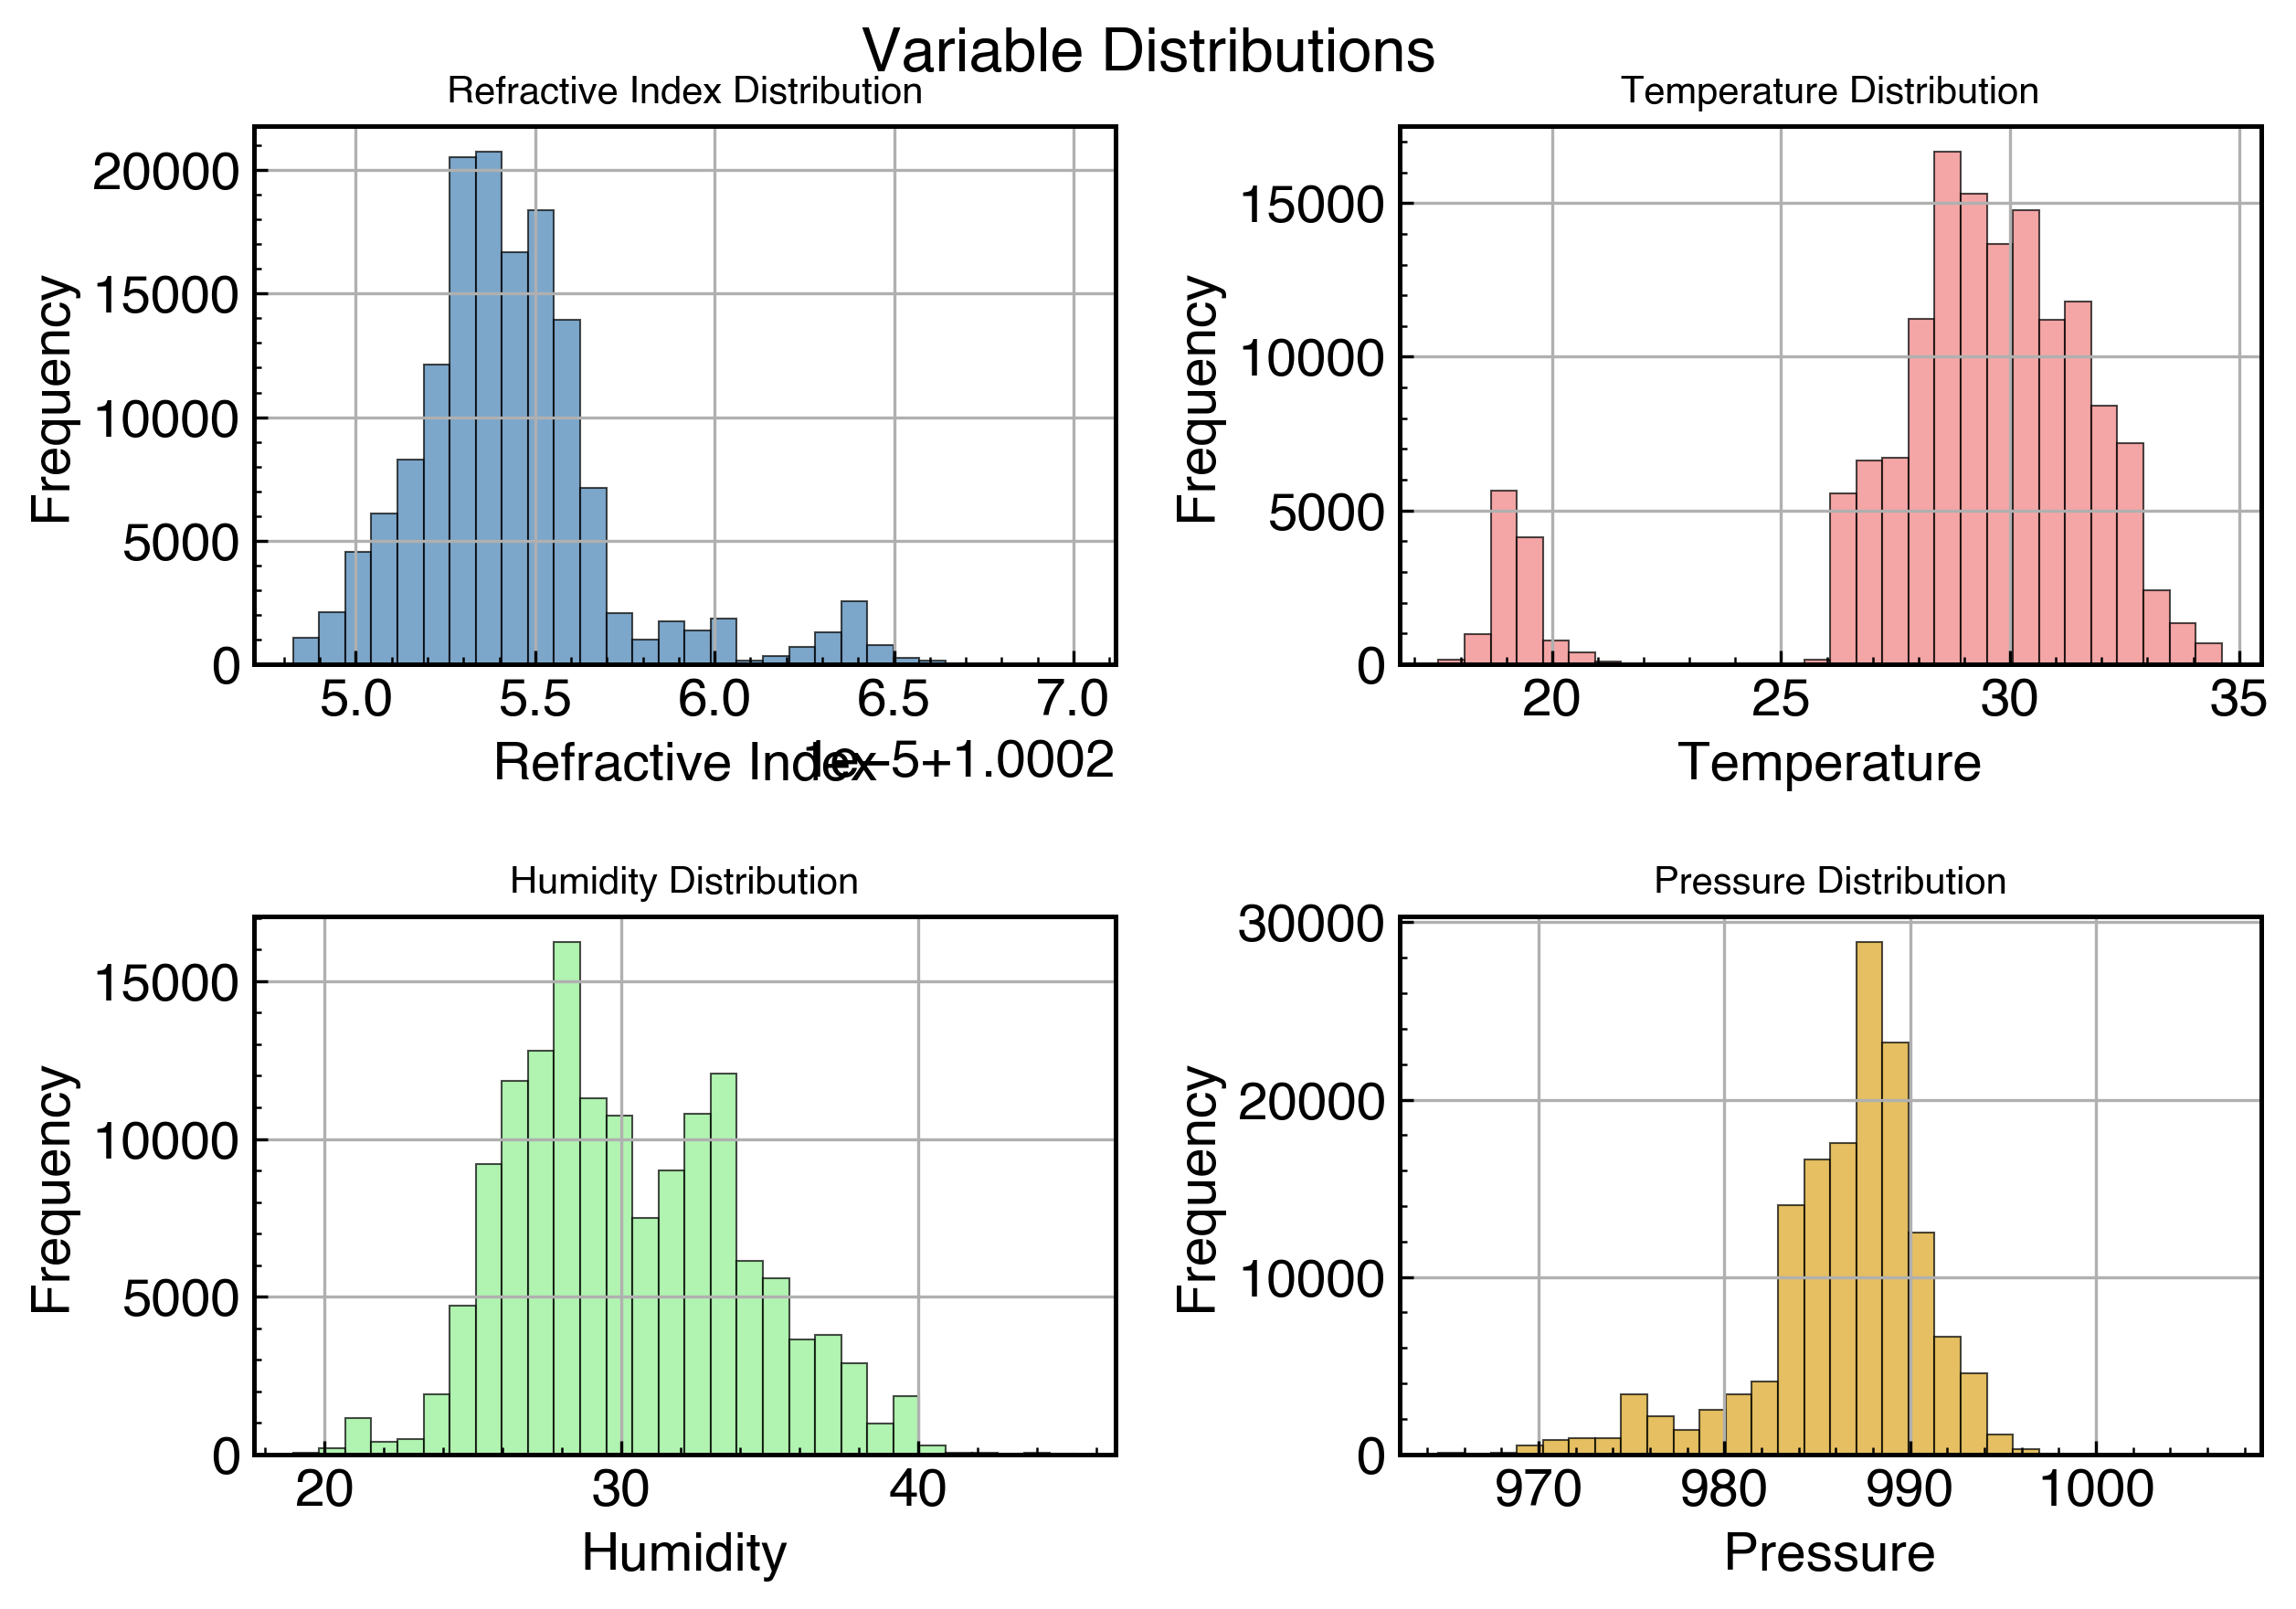

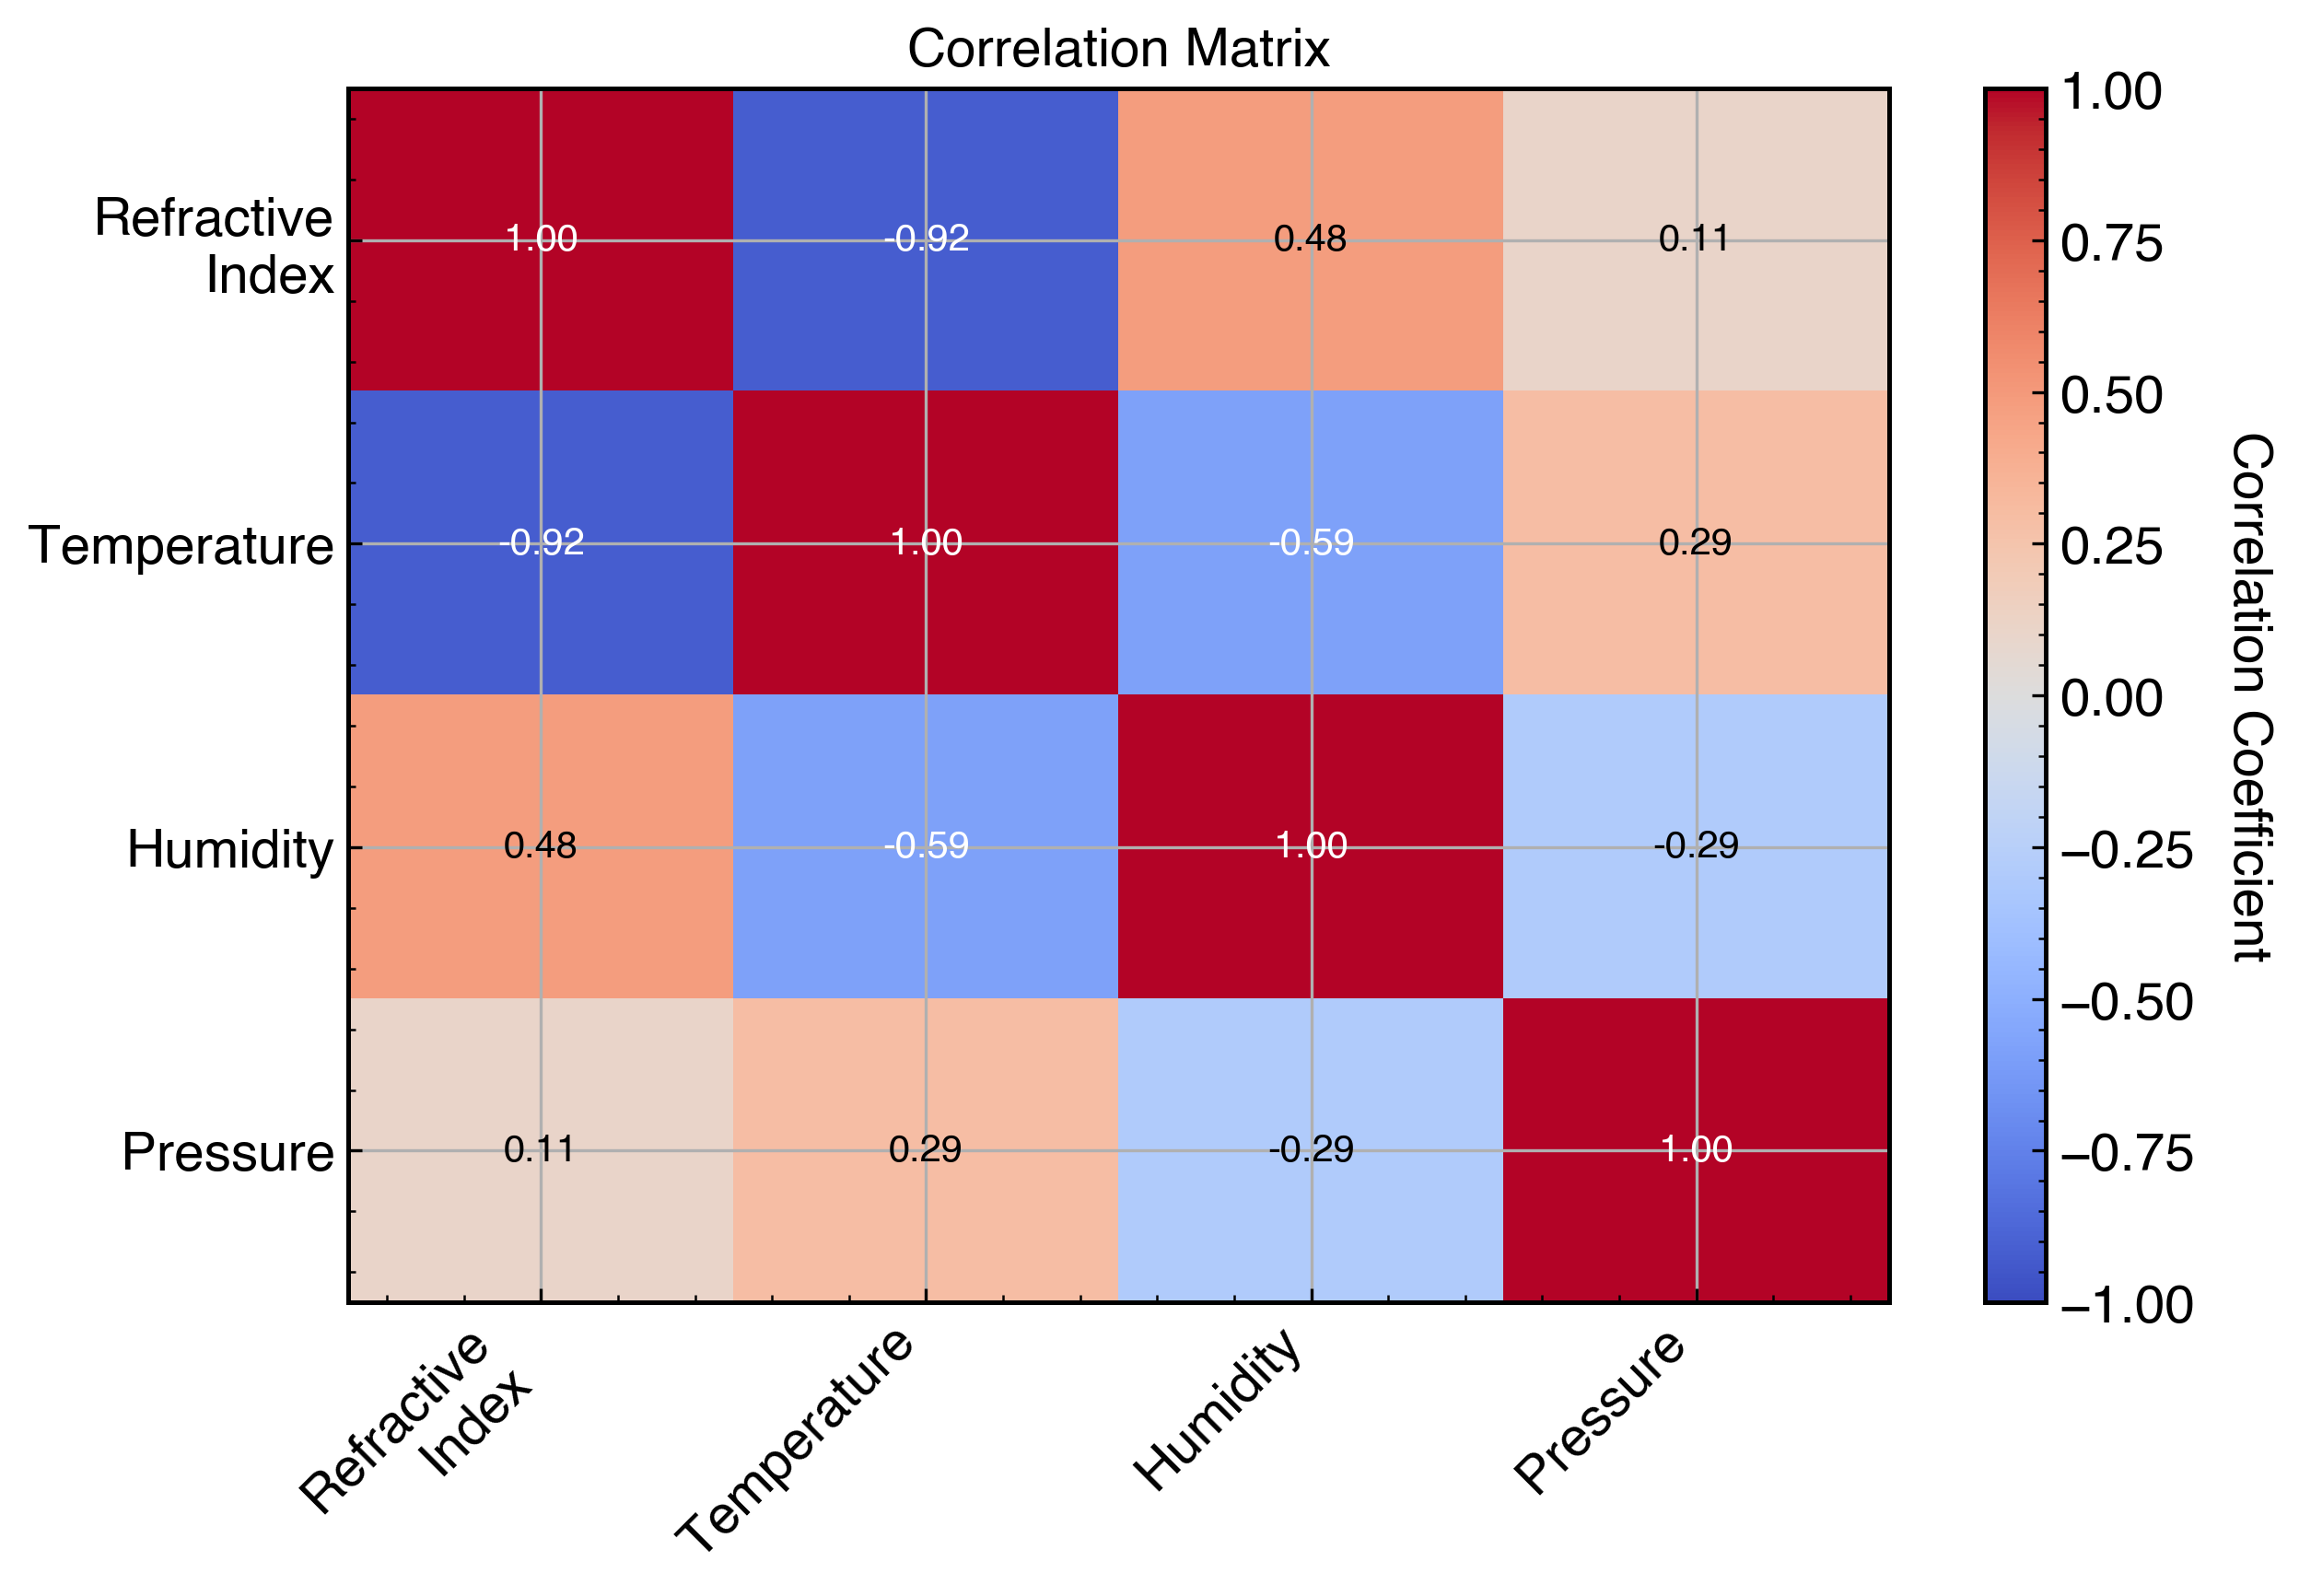

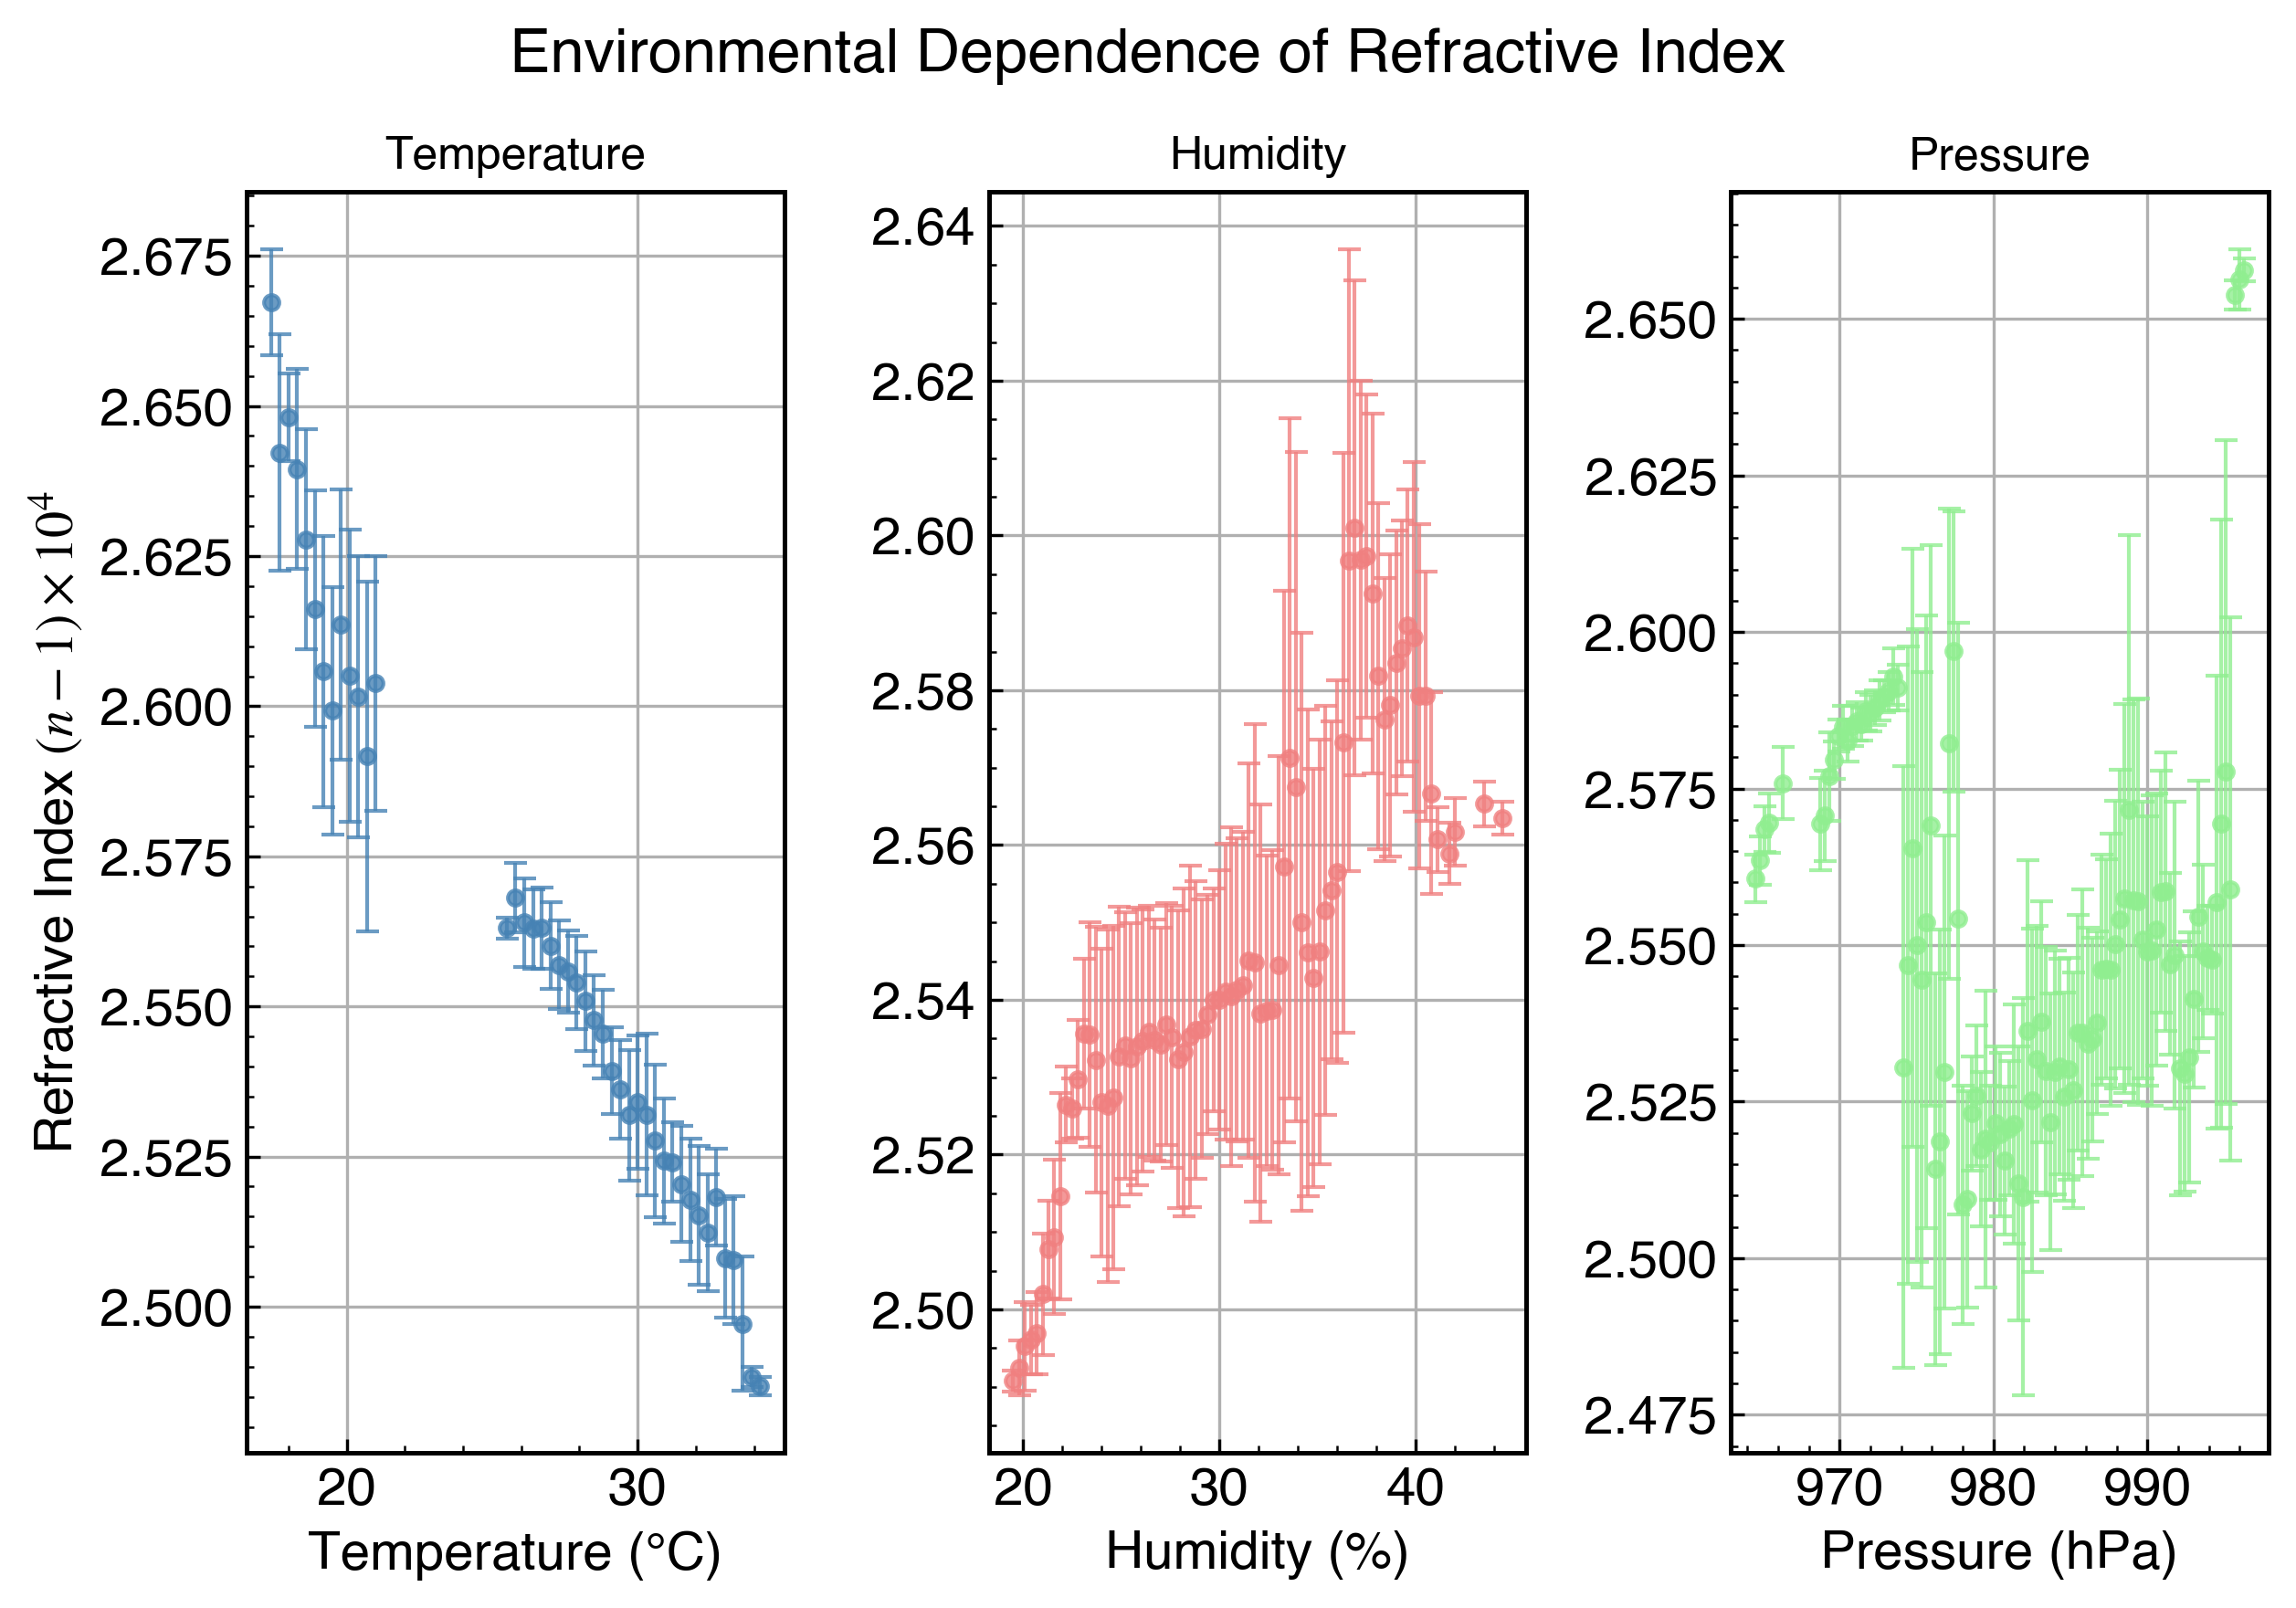

Performing regression analysis...

1. Original OLS with constant:
                            OLS Regression Results                            
Dep. Variable:                 n_1762   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 1.170e+07
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        19:28:07   Log-Likelihood:             2.0543e+06
No. Observations:              145784   AIC:                        -4.109e+06
Df Residuals:                  145780   BIC:                        -4.108e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

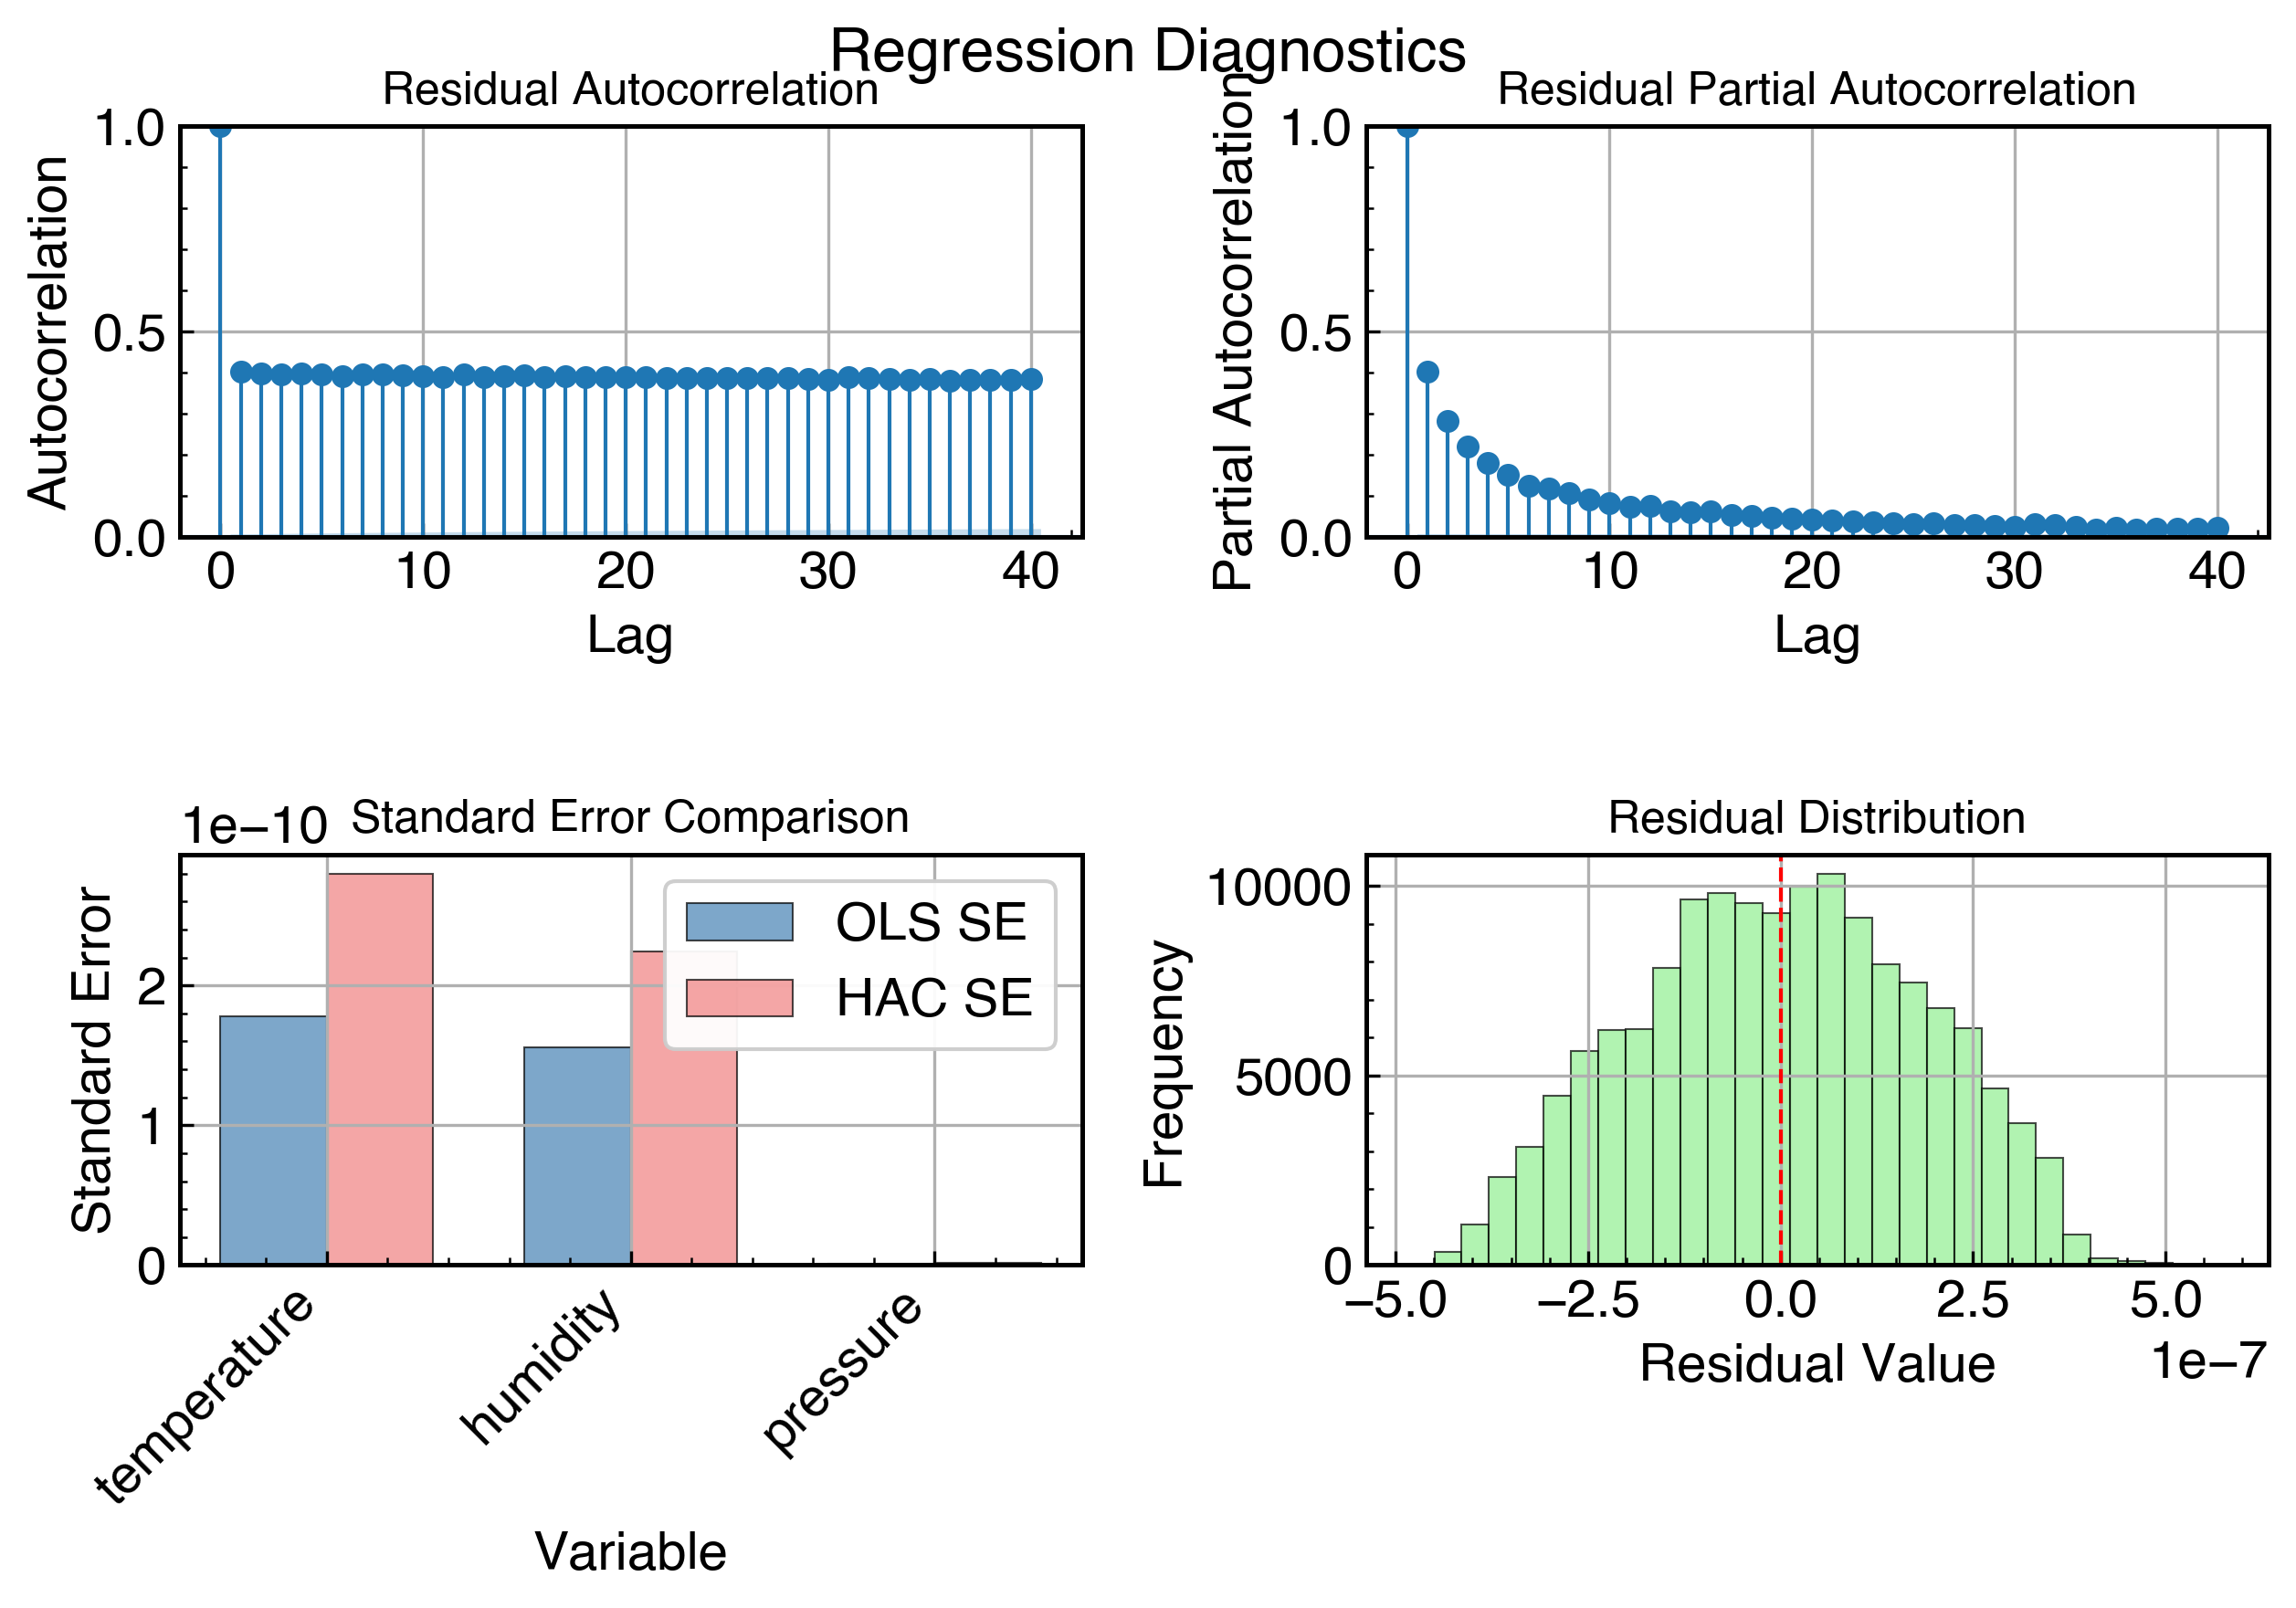

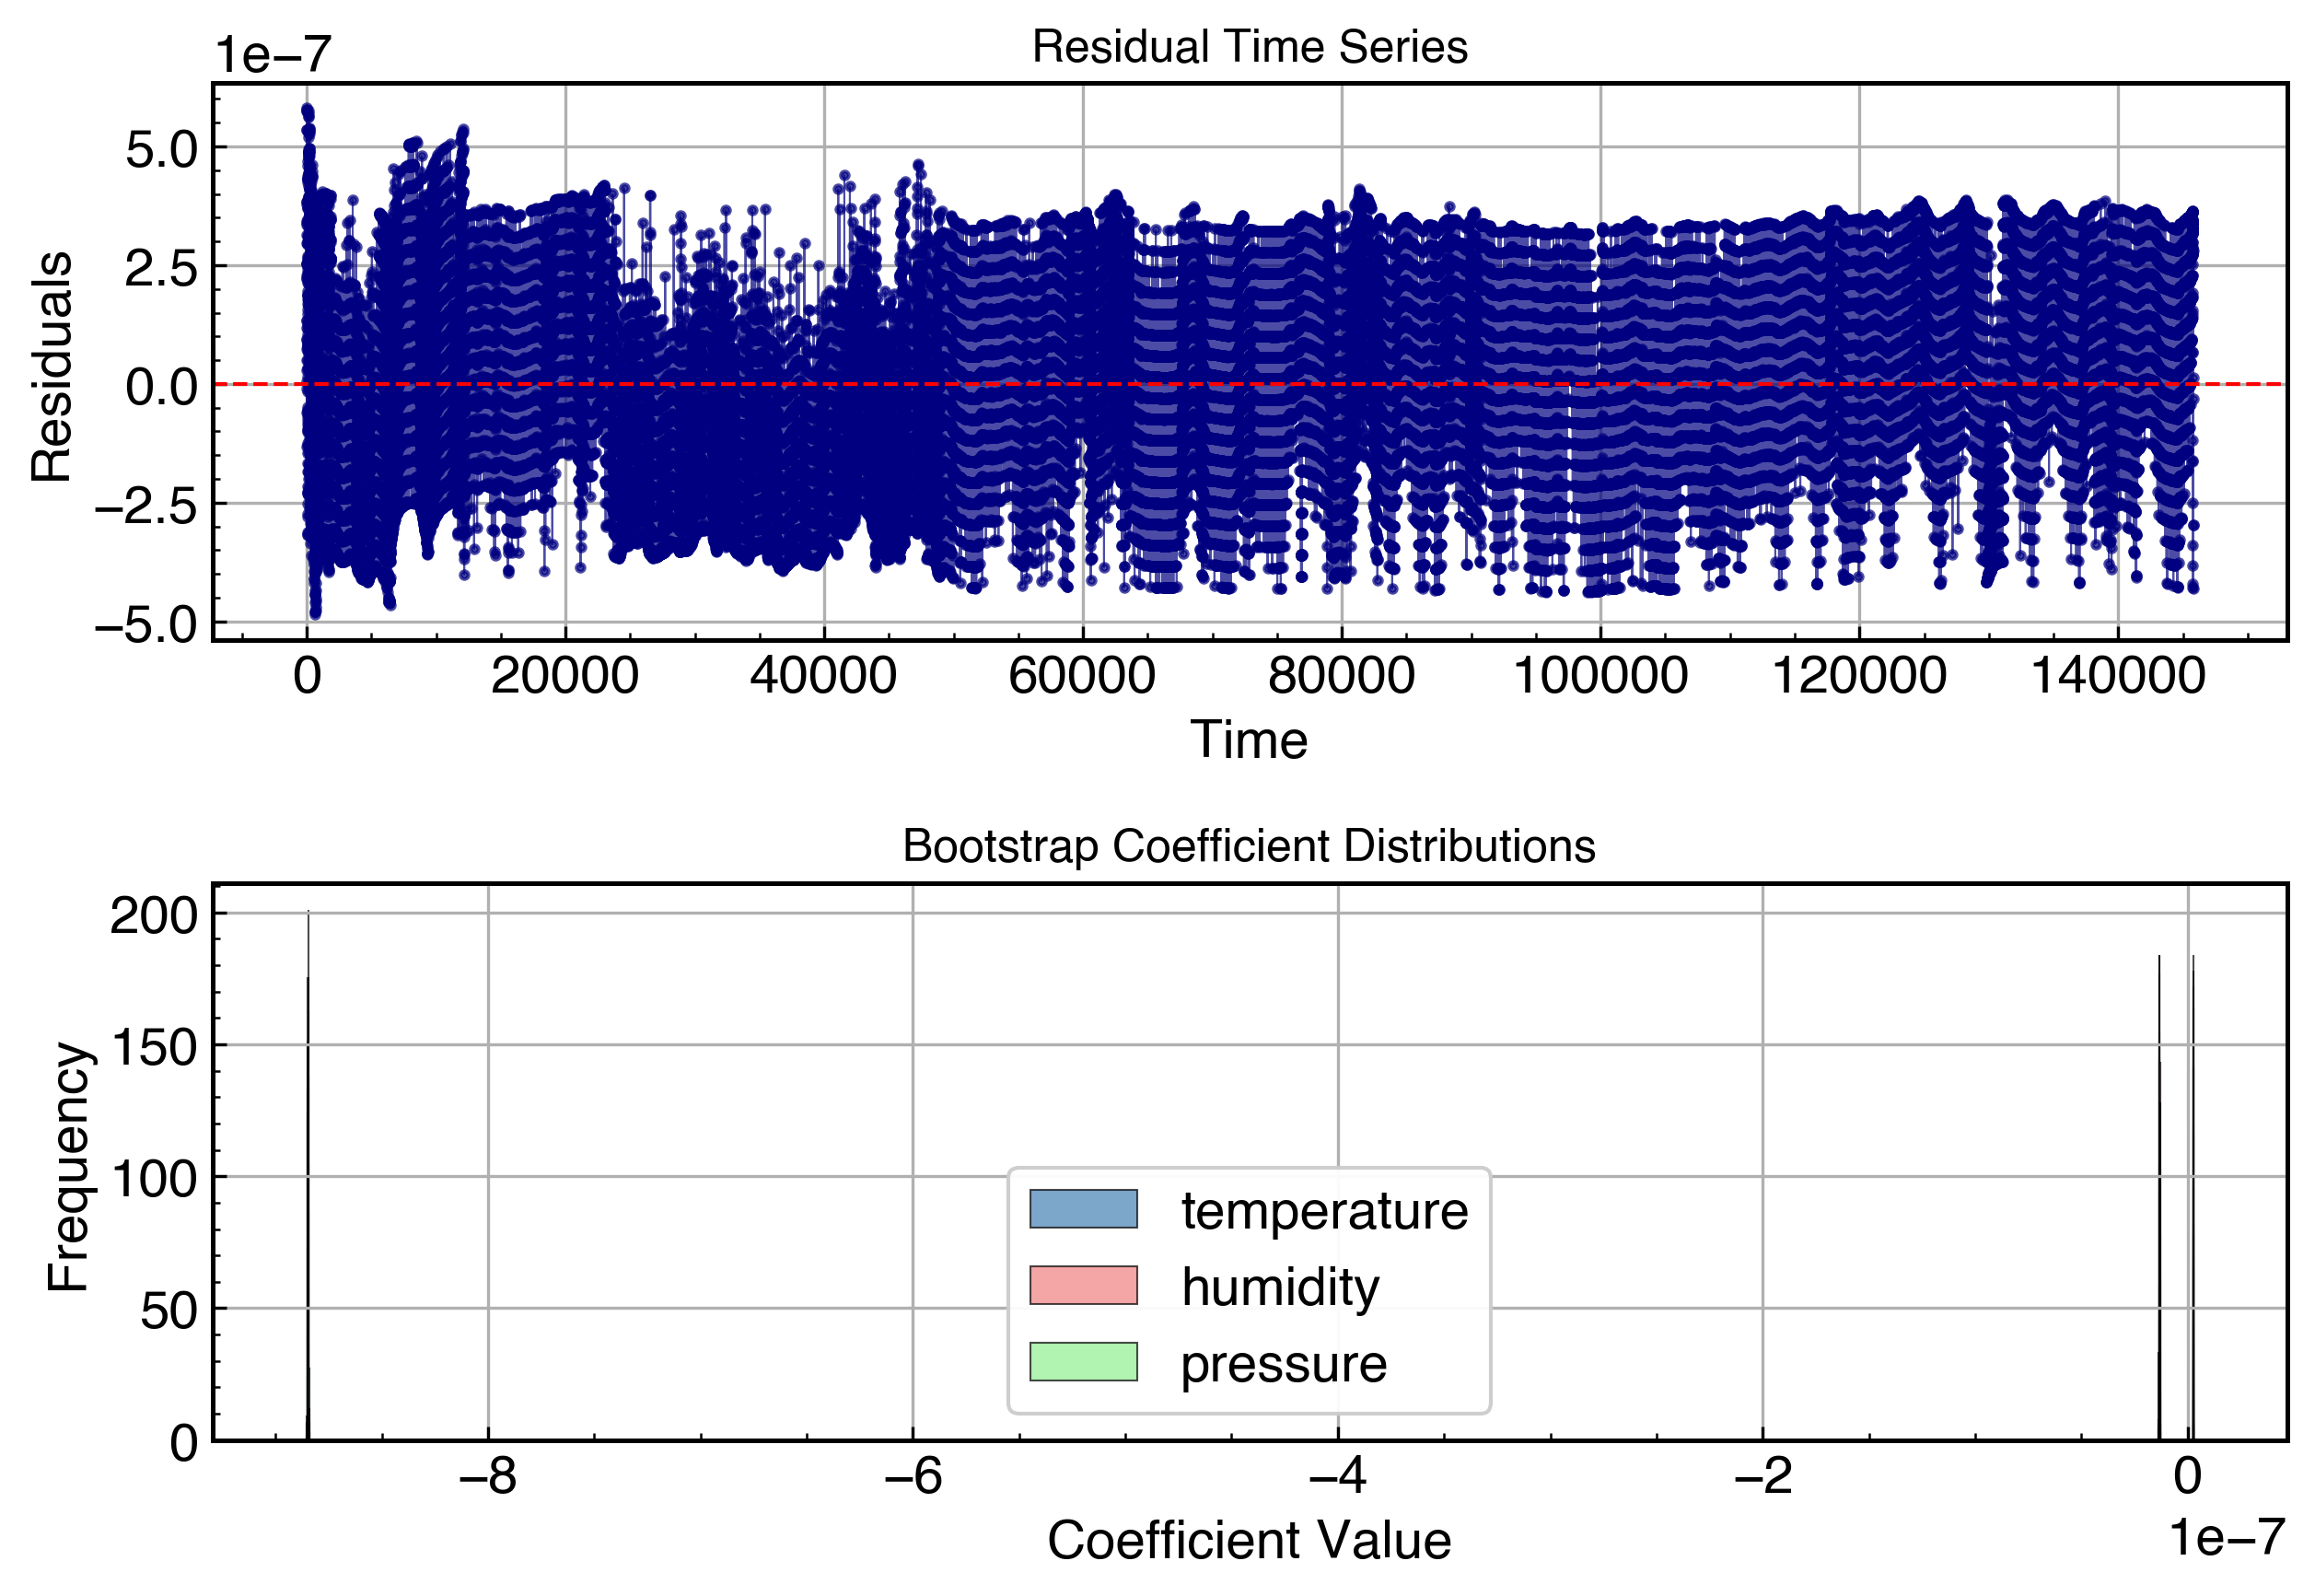

Uncertainty Budget Analysis
Uncertainty Source                 Affected Parameter Estimation Method      Magnitude (1σ)
Finite sample & serial correlation  All coefficients   HAC + Block Bootstrap   1.69e-10    
    Temperature sensor calibration        $\alpha_T$         EIV Monte Carlo   1.42e-10    
       Humidity sensor calibration        $\alpha_H$         EIV Monte Carlo   1.25e-10    
       Pressure sensor calibration        $\alpha_P$         EIV Monte Carlo   9.11e-13    
        780 nm frequency reference     Constant term  Analytical propagation       1e-9    
       1762 nm frequency reference     Constant term  Analytical propagation Negligible    
      Interferometer non-linearity  All coefficients    Upper-bound estimate Negligible    
         Spatial/temporal mismatch Residual variance       Residual analysis   1.84e-07    
Results saved to regression_results.json

Summary of saved data:
  - Models: Original OLS, Centered OLS, HAC, Prais-Winsten
  - Bootstrap iterat

In [2]:
# Load datasets
data_training = pd.read_csv('../../data/processed/full_data.csv')
# Run quality analysis
results, uncertainty_budget = run_analysis(data_training)